In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
 
import math
import numpy as np
import random

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
from torchvision.models import efficientnet_b0
from PIL import Image
from tqdm.notebook import tqdm
from syn2real_dataset import Syn2RealDataset
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
import numpy as np
import math
import os

# Add ../ as a directory to import from
import sys
sys.path.append('../')

In [ ]:
from models.plightning import  MainDataModule

dataset_dir = "../data/20250123_Sideview_40Days"
datamodule = MainDataModule(dataset_dir,
                            image_size=224,
                            load_depth=False,
                            train_batch_size=32, num_workers=1, process_leaf=True, preload=False, side_view=True)
datamodule.setup()

FileNotFoundError: [Errno 2] No such file or directory: '../data/20250123_Sideview_40Days/xml'

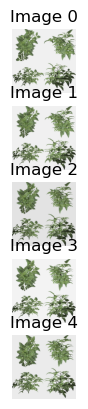

In [ ]:
# Show some images
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import cv2


test_dataloader = datamodule.test_dataloader()
test_dataset = test_dataloader.dataset

n = 5
for i in range(n):
    image, _, vecs, _ = test_dataset[-i-1]
    image = image.permute(1, 2, 0)
    image_rgb = image[:, :, :3]
    img = cv2.normalize(np.array(image_rgb.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(5, 2, 2*i+1)
    plt.imshow(img)
    plt.title(f"Image {i}")
    plt.axis('off')

    if datamodule.load_depth:
        image_depth = image[:, :, 3]
        img = cv2.normalize(np.array(image_depth.cpu()), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
        plt.subplot(5, 2, 2*i+2)
        plt.imshow(img, cmap='gray')
        plt.title("Depth")
        plt.axis('off')

Total 1400 images and plant strings loaded
Total 300 images and plant strings loaded
Total 300 images and plant strings loaded


/tmp/ipykernel_2013331/1261239703.py:88: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out).to(device)


KeyboardInterrupt: 

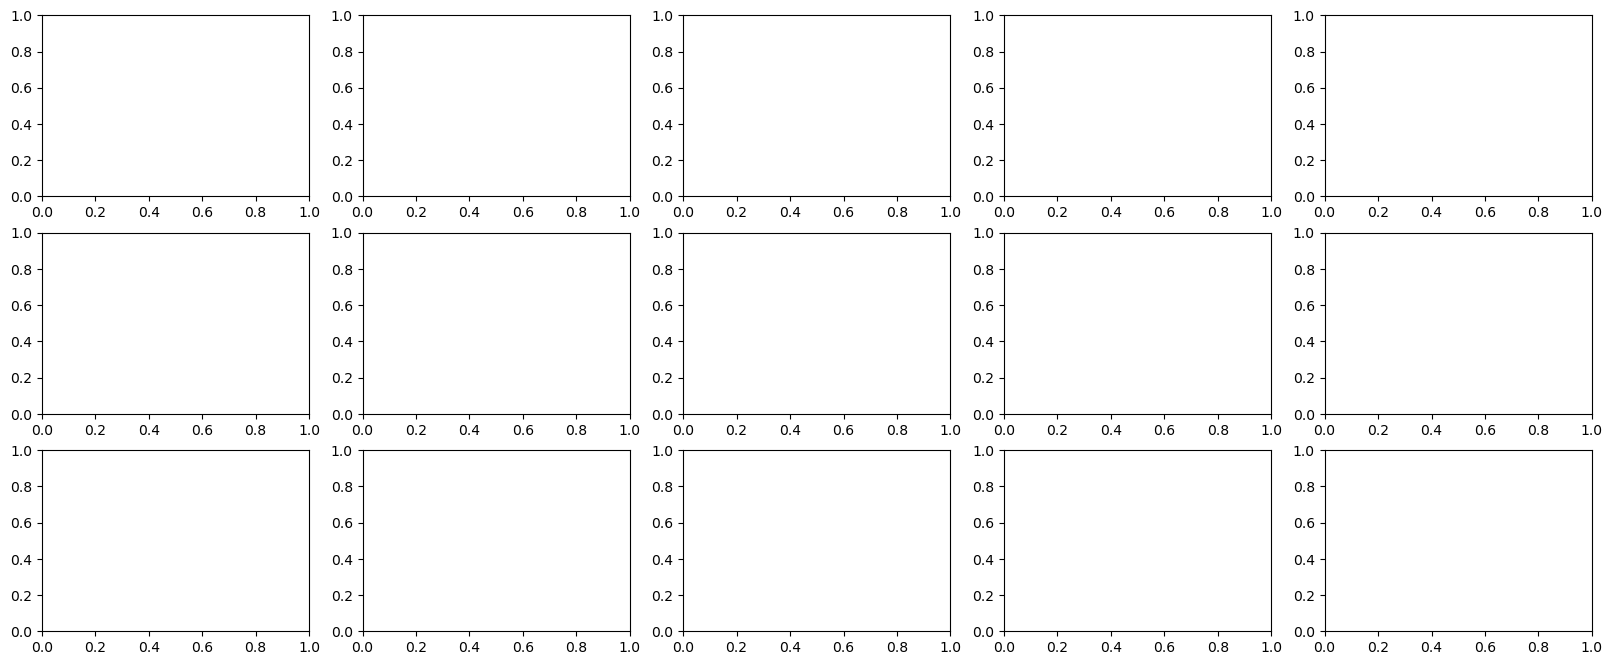

In [4]:
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from models.plightning import MainDataModule

import joblib

from models.plightning import MainModule
from string_to_xml_to_vec import string2vec, vec2string, vec2xml, pretty_print_xml
# model = MainModule()
model_checkpoint_name = "../log/20250320_Quantize_Small_FullTransformer_448_Day1/version_1/checkpoints/best_epoch=13.ckpt"
model = MainModule.load_from_checkpoint(model_checkpoint_name)
model.eval()
# model.freeze()
                      
sideview = False
dataset_dir = "../data/2000_Plots_20241210_Quantized"
from models.plightning import MainDataModule
# growth_stages = [f"{day:02d}" for day in range(0,2)]
datamodule = MainDataModule(dataset_dir,
                            image_size=model.image_size,
                            load_depth=False,
                            train_batch_size=1, num_workers=0, process_leaf=True, preload=False, side_view=sideview,
                            partial_data=1.0,
                            growth_stages = ["01"])
# datamodule.setup(growth_stages=growth_stages)
datamodule.setup()
if 1:
    dataloader = datamodule.test_dataloader()
    #dataloader = datamodule.val_dataloader()
else:
    dataloader = datamodule.train_dataloader()

program_path = "../src/GenerateDataset/build"

# Function to re-render a single XML file
def re_render_xml(output_path, filename, rotation=True):
    image_name = filename.split("/")[-1].split(".")[0]
    os.environ["DISPLAY"] = ":12.0"
    #os.environ["DISPLAY"] = ":1.0"
    # Generate image 
    # Construct the command
    command = ""
    command += f"cd {program_path} && ./main " 
    command += f"-h 1.0 -o {output_path} -name {image_name} -tile none -f {os.path.join(output_path, filename)}"
    if rotation:
        command += " -r"
    result = subprocess.run(command, shell=True, capture_output=True, text=True)
    print(result.stdout)
    print(result.stderr)
    return result

# Prepare the figure
n_figures = 5
fig, axes = plt.subplots(3, n_figures, figsize=(20, 8))

# Create temp folder
temp_folder = "temp"
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = model.image_size
# Process and display 10 images
model.eval()
device = model.device
for idx, (image, plant_info, out, lengths) in enumerate(dataloader):
    if idx >= n_figures:
        break
    
    # print(dataloader.dataset.plant_xml_files[idx])
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    plant_info = plant_info.to(device)

    out = torch.tensor(out).to(device)
    ground_truth = out.squeeze(0).cpu().numpy()

    plant_vec = token2vec(ground_truth)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    if 1:
        re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))
        if 0:
            leaf_area, plant_width, plant_height, leaf_img, _ = process_leaf_image(img, sqaure_crop=False, thr=0.2)
            img = cv2.resize(leaf_img, (image_size, image_size))
        else:
            img = cv2.imread(plant_xml_file_name.replace("xml","jpeg"))
            img = cv2.resize(img, (image_size, image_size))
        gt_img = img.copy()
    
    ############## Generate

    with torch.no_grad():
        result = model.generate(image, plant_info)
        result = result.cpu().numpy()

    plant_vec = token2vec(result)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"temp/plant_{idx}_est.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    re_render_xml(os.path.abspath(temp_folder), os.path.abspath(plant_xml_file_name))

    img, _ = load_sideview_images(temp_folder, plant_xml_file_name.replace("xml","jpeg"), model.image_size, True)

    image_vis = image[0].permute(1, 2, 0).cpu()

    image_vis = cv2.normalize(np.array(image_vis), None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U)
    row, col = divmod(idx, n_figures)
    axes[row, col].imshow(image_vis[:, :, 0:3])
    axes[row, col].set_title(f"Input Image {idx + 1}")
    axes[row, col].axis('off')

    # axes[row+1, col].imshow(gt_img[:, :, 0:3])
    # axes[row+1, col].set_title(f"Re-Renderd Image {idx + 1}")
    # axes[row+1, col].axis('off')

    # depth = model.predicted_depth.squeeze().cpu()
    # axes[row+1, col].imshow(depth)
    # axes[row+1, col].set_title(f"Estimated Depth Image {idx + 1}")
    # axes[row+1, col].axis('off')

    axes[row + 2, col].imshow(img)
    axes[row + 2, col].set_title(f"Output Model {idx + 1}")
    axes[row + 2, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import torchvision.transforms as T
# Visualize Vision Transformer Output
num_patches = 16
for idx, (image, plant_info, out, lengths) in enumerate(dataloader):
    image = image.to(device)
    plant_info = plant_info.to(device)
    feature = model.image_encoder(image, plant_info)
    
    # Convert image to NumPy
    image_np = T.ToPILImage()(image[0].cpu())
    feature_map_overlay = feature[:, :256, 0].reshape(num_patches, num_patches, -1).detach().cpu().numpy()
    feature_map_resized = cv2.resize(feature_map_overlay, image_np.size[::-1])

    # Create 1x2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot original image
    axes[0].imshow(image_np)
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Plot feature map overlay
    #im = axes[1].imshow(image_np)
    im = axes[1].imshow(feature_map_resized, cmap='jet', alpha=1.0)
    axes[1].set_title("Feature Map Overlay")
    axes[1].axis("off")

    # Add colorbar to the second subplot
    cbar = fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("Feature Intensity")

    plt.tight_layout()
    plt.show()
    break

RuntimeError: shape '[32, 32, -1]' is invalid for input of size 256

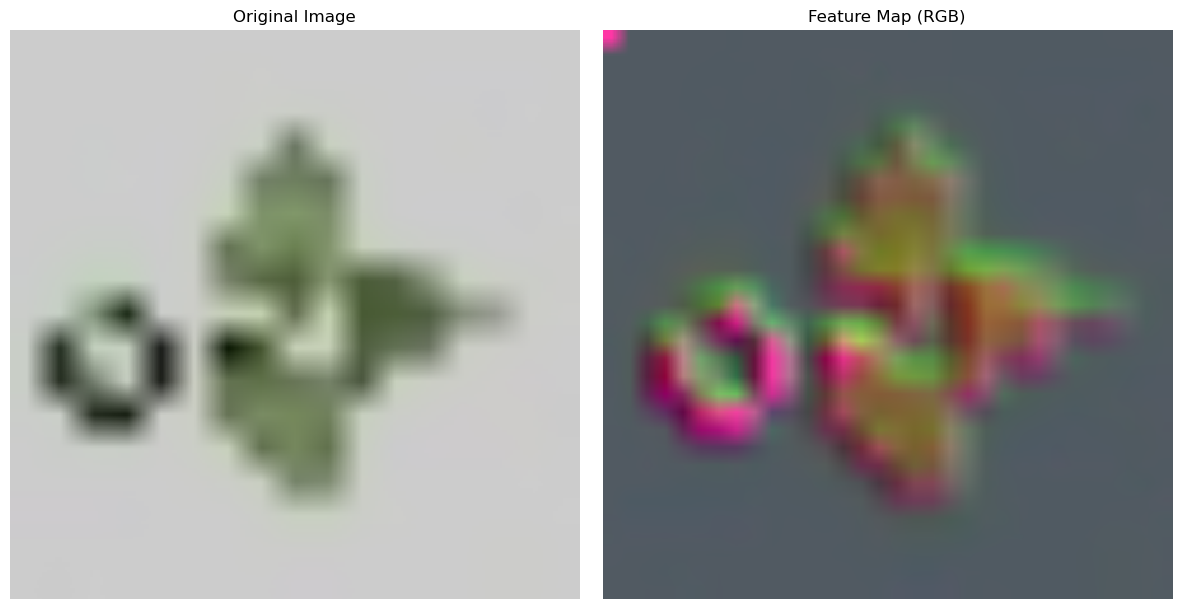

In [3]:
import torchvision.transforms as T
import matplotlib.pyplot as plt
import cv2
from sklearn.decomposition import PCA
import numpy as np

# Visualize Vision Transformer Output
img_size = 448
model = MainModule(image_size=img_size).to(device)
num_patches = img_size // 14
resize_T = T.Resize(img_size)
for idx, (image, plant_info, out, lengths) in enumerate(dataloader):
    image = image.to(device)
    image = resize_T(image)
    plant_info = plant_info.to(device)
    feature = model.image_encoder(image, plant_info)  # Shape: (batch_size, num_patches, feature_dim)

    # Convert image to NumPy
    image_np = T.ToPILImage()(image[0].cpu().to(torch.uint8))

    # Extract the feature map for the first image in the batch
    feature_map = feature[:, :-2].squeeze().detach().cpu().numpy()  # Shape: (num_patches, feature_dim)

    # Apply PCA to reduce 768 dimensions to 3
    pca = PCA(n_components=3)
    feature_map_pca = pca.fit_transform(feature_map)  # Shape: (num_patches, 3)

    # Normalize PCA output to [0, 1] for RGB mapping
    feature_map_normalized = (feature_map_pca - feature_map_pca.min()) / (feature_map_pca.max() - feature_map_pca.min())

    # Reshape to a 2D grid (num_patches x num_patches x 3)
    feature_map_rgb = feature_map_normalized.reshape(num_patches, num_patches, 3)

    # Resize the feature map to match the image size
    feature_map_resized = cv2.resize(feature_map_rgb, image_np.size[::-1])

    # Create 1x2 subplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot original image
    axes[0].imshow(image_np, interpolation='none')  # Disable interpolation
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    # Plot RGB feature map
    axes[1].imshow(feature_map_resized, interpolation='none')  # Disable interpolation
    axes[1].set_title("Feature Map (RGB)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()
    break

In [3]:
import torch

# 크기가 [2, 1, 18]인 텐서 생성 (0으로 초기화)
tensor_18 = torch.zeros((2, 1, 18))

# 크기가 [2, 1, 1]인 텐서 생성 (여기서는 임의의 값으로 초기화)
tensor_1 = torch.tensor([[[5]], [[10]]])  # 예시 값을 사용

# k 값 정의 (예: k = 3)
k = 3

# tensor_1을 tensor_18과 같은 차원으로 확장하여 [:,:,k] 위치에 값 할당
tensor_18[:, :, k] = tensor_1[:, :, 0]  # 이 경우 tensor_1의 0번째 차원을 가져옵니다.

print("tensor_18:")
print(tensor_18)

tensor_18:
tensor([[[ 0.,  0.,  0.,  5.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
           0.,  0.,  0.,  0.]],

        [[ 0.,  0.,  0., 10.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
           0.,  0.,  0.,  0.]]])


In [ ]:
# Inference all the test images and save
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from plant_tokenizer import SOS_vec_padded, SOS_TOKEN, EOS_TOKEN
from models.model import get_tgt_mask
from plant_dataset import PlantDataset, load_sideview_images
from image_process import process_leaf_image
from plantstring2model import plantstring2model
from string_to_xml_to_vec import vec2xml, recursive_to_linked
from plant_tokenizer import token2vec
import subprocess
import shutil
from models.plightning import MainDataModule
import joblib
from tqdm import tqdm
import cv2

datamodule = MainDataModule(dataset_dir,
                            image_size=model.image_size,
                            load_depth=False,
                            train_batch_size=1, num_workers=0, process_leaf=True, preload=False, side_view=True)
datamodule.setup()
dataloader = datamodule.test_dataloader()

# Create temp folder
temp_folder = model_checkpoint_name.split("/")[2]
shutil.rmtree(temp_folder, ignore_errors=True)
os.makedirs(temp_folder, exist_ok=True)

image_size = model.image_size
# Process and display 10 images
model.eval()
device = model.device
for idx, (image, plant_info, out, lengths) in enumerate(tqdm(dataloader)):
    if image.dim() == 3:
        image = image.unsqueeze(0)

    image = image.to(device)
    plant_info = plant_info.to(device)


    ############## Generate
    with torch.no_grad():
        result = model.generate(image, plant_info, mode='quantize')
        result = result.cpu().numpy()
    try:
        plant_vec = token2vec(result)
        plant_xml = vec2xml(plant_vec)
        plant_xml = recursive_to_linked(plant_xml)
        plant_xml_str = pretty_print_xml(plant_xml)
        plant_xml_file_name = f"{temp_folder}/plant_{idx}_quantize_est.xml"
        with open(plant_xml_file_name, "w") as f:
            f.write(plant_xml_str)
    except Exception as e:
        print(e)
        continue

    with torch.no_grad():
        result = model.generate(image, plant_info, mode='regression')
        result = result.cpu().numpy()
    try:
        plant_vec = token2vec(result)
        plant_xml = vec2xml(plant_vec)
        plant_xml = recursive_to_linked(plant_xml)
        plant_xml_str = pretty_print_xml(plant_xml)
        plant_xml_file_name = f"{temp_folder}/plant_{idx}_regression_est.xml"
        with open(plant_xml_file_name, "w") as f:
            f.write(plant_xml_str)
    except Exception as e:
        print(e)
        continue

    with torch.no_grad():
        result = model.generate(image, plant_info, mode='mix')
        result = result.cpu().numpy()
    try:
        plant_vec = token2vec(result)
        plant_xml = vec2xml(plant_vec)
        plant_xml = recursive_to_linked(plant_xml)
        plant_xml_str = pretty_print_xml(plant_xml)
        plant_xml_file_name = f"{temp_folder}/plant_{idx}_mix_est.xml"
        with open(plant_xml_file_name, "w") as f:
            f.write(plant_xml_str)
    except Exception as e:
        print(e)
        continue

    # Save the GT too
    ground_truth = out.squeeze(0).cpu().numpy()
    # Unscale it 
    plant_vec = token2vec(ground_truth)
    plant_xml = vec2xml(plant_vec)
    plant_xml_file_name = f"{temp_folder}/plant_{idx}_gt.xml"
    plant_xml = recursive_to_linked(plant_xml)
    plant_xml_str = pretty_print_xml(plant_xml)
    with open(plant_xml_file_name, "w") as f:
        f.write(plant_xml_str)

    # Save GT Image, too
    gt_image_file_path = f"{temp_folder}/plant_{idx}_gt.jpg"
    cv_image = cv2.cvtColor(image.squeeze(0).permute(1,2,0).cpu().numpy(),cv2.COLOR_BGR2RGB)
    cv2.imwrite(gt_image_file_path, image.squeeze(0).permute(1,2,0).cpu().numpy())

Total 20000 images and plant strings loaded
Total 10000 images and plant strings loaded
Total 10000 images and plant strings loaded


 70%|████████████████████████████████████████████████████████████████████▏                            | 7027/10000 [22:23:35<9:21:21, 11.33s/it]

In [ ]:
# Draw a 14x14 grid on the image_vis[:,:,0:3]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_vis[:,:,0:3])
axes[0].set_title("Input Image")
axes[0].axis('off')

for i in range(1, 14):
    axes[0].axvline(i*16, color='r', linestyle='--')
    axes[0].axhline(i*16, color='r', linestyle='--')
    axes[1].axvline(i*16, color='r', linestyle='--')
    axes[1].axhline(i*16, color='r', linestyle='--')
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import cv2

from utils import visualize_attention
from string_to_xml_to_vec import plant_string2words
from plant_tokenizer import token2vec

# Visualize attention
# Example words
plant_vec = token2vec(result)
plant_xml = vec2string([plant_vec])

words = plant_string2words(plant_xml)
print(words)

if 0:
    # Add <SOS> to the beginning of the list of words
    words = ["<SOS>"] + words
else:
    # Add <EOS> to the end of the list of words
    words = words + ["<EOS>"]

def shorten_title(title, max_length=10):
    """Shorten the title if it is too long."""
    if "foliate" in title:
        title = "Shoot"
    elif "Internode" in title:
        title = "Internode"
    elif "Petiole" in title:
        title = "Petiole"
    elif "Leaf" in title:
        title = "Leaf"
    return title

# Create a word_dimx3 subplot
multihead_attn_weights = model.sequence_decoder.multihead_attn_weights
image_dict = {}
num_cols = 10  # Number of images per row

for layer_index in range(len(multihead_attn_weights)):
    num_rows = (len(words) + num_cols - 1) // num_cols  # Calculate the number of rows needed
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 2, num_rows * 2))
    fig.suptitle(f'Layer {layer_index + 1}', fontsize=16)
    
    for word_index in range(len(words)):
        row = word_index // num_cols
        col = word_index % num_cols
        overlay = visualize_attention(image_vis, multihead_attn_weights, words, word_index, layer_index, interpolation=cv2.INTER_NEAREST)
        image_dict[(layer_index, word_index)] = overlay
        axes[row][col].imshow(overlay)
        axes[row][col].axis('off')
        short_title = shorten_title(words[word_index])
        axes[row][col].set_title(f"{word_index}:{short_title}", rotation=0, ha='right', fontsize=8)
    
    # Hide any unused subplots
    for i in range(len(words), num_rows * num_cols):
        row = i // num_cols
        col = i % num_cols
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, wspace=0.3, hspace=0.3)  # Adjust the top to make room for the suptitle and add space between subplots
    plt.show()

In [ ]:
# Create a output folder
output_dir = "attention_output"
# Remove the folder if it exists
if os.path.exists(output_dir):
    import shutil
    shutil.rmtree(output_dir)
if not os.path.exists(output_dir):
    os.makedirs(output_dir)



# Save the attention images
for key, img in image_dict.items():
    layer_index, word_index = key
    img_vis = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    file_name = f"layer_{layer_index}_word_{word_index}_{words[word_index]}.png"
    file_path = os.path.join(output_dir, file_name)
    cv2.imwrite(file_path, img_vis)